# Task 2: Simple Linear Regression Model


Build a linear regression model to predict house prices using the California Housing dataset.


1. Load and preprocess the dataset
2. Train a linear regression model using scikit-learn
3. Interpret the model coefficients
4. Evaluate the model using R-squared and MSE

## Step 1: Import Required Libraries

In [18]:
# pip install pandas numpy scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt


Libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [20]:
# Load the California Housing dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (20640, 9)

First few rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64

## Step 3: Preprocess the Data

In [21]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Prepare features (X) and target (y)
X = df.drop('PRICE', axis=1)
y = df['PRICE']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

Training set size: 16512
Testing set size: 4128
Number of features: 8


## Step 4: Train the Linear Regression Model

In [29]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("="*50)
print("MODEL TRAINING COMPLETED")
print("="*50)

MODEL TRAINING COMPLETED


## Step 5: Interpret Model Coefficients

In [23]:
# Interpret model coefficients
print("Model Coefficients:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)
print(coef_df)
print(f"\nIntercept: {model.intercept_:.4f}")

print("\n" + "="*50)
print("COEFFICIENT INTERPRETATION:")
print("="*50)
print("Positive coefficients indicate features that increase house price.")
print("Negative coefficients indicate features that decrease house price.")
print("Larger absolute values indicate stronger impact on price.")

Model Coefficients:
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708

Intercept: -37.0233

COEFFICIENT INTERPRETATION:
Positive coefficients indicate features that increase house price.
Negative coefficients indicate features that decrease house price.
Larger absolute values indicate stronger impact on price.


## Step 6: Make Predictions

In [24]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions completed!")
print(f"Sample predictions (first 5): {y_test_pred[:5]}")
print(f"Actual values (first 5): {y_test.values[:5]}")

Predictions completed!
Sample predictions (first 5): [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
Actual values (first 5): [0.477   0.458   5.00001 2.186   2.78   ]


## Step 7: Evaluate the Model (R-squared and MSE)

In [25]:
# Evaluate the model
print("="*50)
print("MODEL EVALUATION")
print("="*50)

# Training set metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

print("\nTraining Set Performance:")
print(f"R-squared (R²): {train_r2:.4f}")
print(f"Mean Squared Error (MSE): {train_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {train_rmse:.4f}")

# Testing set metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("\nTesting Set Performance:")
print(f"R-squared (R²): {test_r2:.4f}")
print(f"Mean Squared Error (MSE): {test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.4f}")

print("\n" + "="*50)
print("METRICS INTERPRETATION:")
print("="*50)
print(f"R² Score: {test_r2:.2%} of variance in house prices is explained by the model")
print("Higher R² (closer to 1.0) indicates better fit")
print(f"MSE: Average squared difference between predictions and actual values")
print(f"RMSE: {test_rmse:.4f} (in same units as target variable)")

MODEL EVALUATION

Training Set Performance:
R-squared (R²): 0.6126
Mean Squared Error (MSE): 0.5179
Root Mean Squared Error (RMSE): 0.7197

Testing Set Performance:
R-squared (R²): 0.5758
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456

METRICS INTERPRETATION:
R² Score: 57.58% of variance in house prices is explained by the model
Higher R² (closer to 1.0) indicates better fit
MSE: Average squared difference between predictions and actual values
RMSE: 0.7456 (in same units as target variable)


## Step 8: Visualize Results

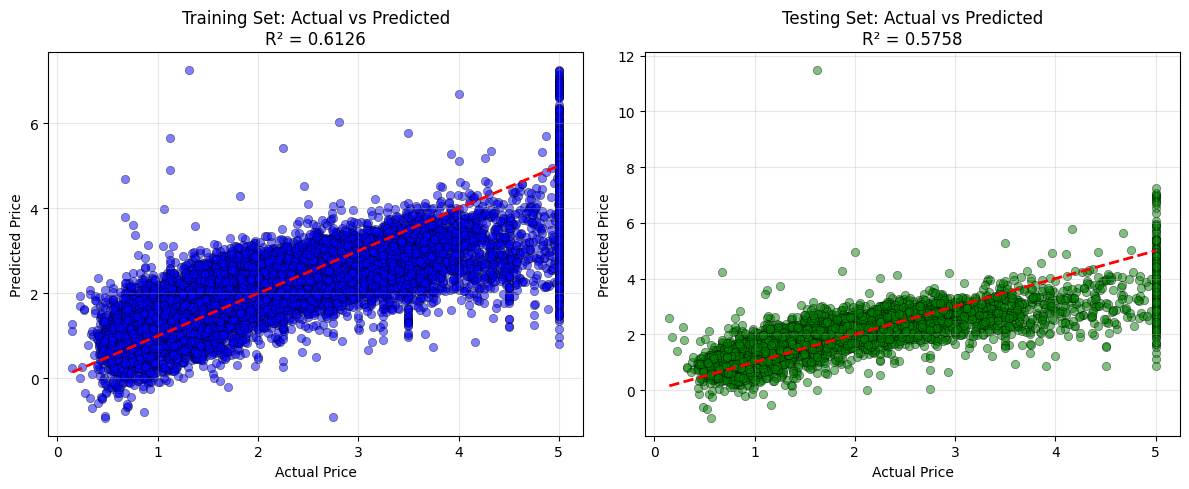

In [26]:
# Visualize predictions vs actual values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', edgecolors='k', linewidth=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Testing Set: Actual vs Predicted\nR² = {test_r2:.4f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

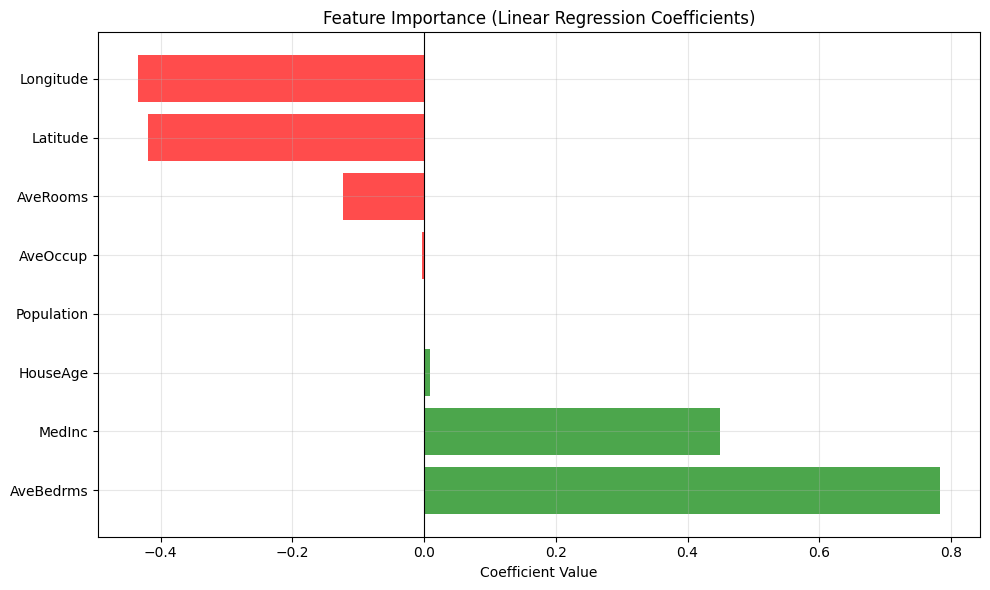

In [27]:
# Feature importance visualization
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()